In [1]:
using Slepians
using Distributed 
import Pkg;

@everywhere using FastGaussQuadrature, Plots, LinearAlgebra, SpecialFunctions, FFTW, SharedArrays
@everywhere using BenchmarkTools, Distributed, DistributedArrays, .Threads, SparseArrays, Hwloc

In [2]:
using Hwloc
Hwloc.num_physical_cores()
#should return the number of cores your computer has 
#works better if your computer has at least 4 cores 

10

In [3]:
nthreads()

1

In [4]:
custom_config = BenchmarkTools.DEFAULT_PARAMETERS.samples = 100 # Number of samples
custom_config = BenchmarkTools.DEFAULT_PARAMETERS.evals = 1 # Number of evaluations per sample
custom_config = BenchmarkTools.DEFAULT_PARAMETERS.seconds = 300 # Minimum time for benchmarking in seconds

#customizes benchmark tools to run for a longer time so that more samples can be taken
#such that the results are more accurate

300

In [5]:
# The underlying Kernel function, equation 54c in Simons 2012.
function Dfun(x::Vector{Float64}, y::Vector{Float64}, Kp::Float64)
    out   = 0.0
    if x == y
        out = abs2(Kp)/(4.0*pi)
    else
        out = Kp*besselj1(Kp*norm(x-y))/(2.0*pi*norm(x-y))
    end
    return out
end

Dfun (generic function with 1 method)

In [6]:
function Dmatrix(Kp::Float64, pts1::Vector{Vector{Float64}}, 
                 pts2::Vector{Vector{Float64}})::Matrix{Float64}
    Out = zeros(length(pts1), length(pts2))
    @simd for j in eachindex(pts1)
        @simd for k in eachindex(pts2)
            @inbounds Out[j,k] = Dfun(pts1[j], pts2[k], Kp)
        end
    end
    return Out
end

Dmatrix (generic function with 1 method)

In [7]:
function helpPlot(data, n::Int64, fft::Bool, em::Int64)
    if fft
        onedata = fftshift(abs2.(fft(data[n])))
    else
        onedata = data[n]
    end
    sl = em
    slices = Vector{Matrix{Float32}}(undef, sl)
    for i in 1:sl
        slices[i] = onedata[:, :, i]
    end

    Plots.gr()

    heatmaps = []
    global_min = minimum(vcat(slices...))
    global_max = maximum(vcat(slices...))

    for (i, slice) in enumerate(slices)
        push!(heatmaps, Plots.heatmap((slice), title="Slice $i", xlabel="X-axis", ylabel="Y-axis", color=:turbo, colorbar=true, clims=(global_min, global_max)))
    end
    return heatmaps
end


helpPlot (generic function with 1 method)

In [8]:
function cuboidSleps(nslep::Int64, n::Int64, m::Int64, q::Int64, Kp::Float64, N::Int64,
                   M::Int64, Q::Int64, verbose::Bool=false, which::Int64=1)

    # Get the quadrature weights and nodes for each dimensions:
    no1, wt1 = gausslegendre(N)
    no2, wt2 = gausslegendre(M)
    no3, wt3 = gausslegendre(Q)

    no       = collect.(collect(Iterators.product(no1, no2, no3))[:])
    wtv      = prod.(collect(Iterators.product(wt1, wt2, wt3))[:])

    # set up the eigenvalue problem and factorize:
    Kf       = Dmatrix(Kp, no, no)
    W        = Diagonal(sqrt.(wtv))
    solvme   = Symmetric(W*Kf*W)
    factd    = eigen(solvme)

    # Extract the slepians, show the concentrations if verbose:
    goodind  = sortperm(factd.values, rev=true)[1:nslep]
    if verbose
        println("The $(nslep) concentrations:")
        for j in 1:nslep
            println(factd.values[goodind[j]])
        end
    end

    # Get the number of requested sleps:
    points   = collect.(collect(Iterators.product(LinRange(-1.0, 1.0, n), LinRange(-1.0, 1.0, m), LinRange(-1.0, 1.0, q)))[:])
    sleps    = Array{Float64, 3}[]
    s = Array{Float64, 3}
    for l in 1:nslep
        newslep = zeros(Float64, q*n*m)
        @simd for j in eachindex(points)
            @simd for k in eachindex(no)
                @inbounds newslep[j] += wtv[k]*Dfun(no[k], points[j], Kp)*factd.vectors[:,goodind[l]][k]
            end
        end
        s = reshape(newslep, n,m,q)./factd.values[goodind[l]]
        push!(sleps, s)
    end
    return helpPlot(sleps, which, false, q)
end


cuboidSleps (generic function with 3 methods)

In [9]:
function cuboidSlepsFastNC(nslep::Int64, n::Int64, m::Int64, q::Int64, Kp::Float64, N::Int64,
                   M::Int64, Q::Int64, verbose::Bool=false, which::Int64=1)

    # Get the quadrature weights and nodes for each dimensions:
    no1, wt1 = gausslegendre(N)
    no2, wt2 = gausslegendre(M)
    no3, wt3 = gausslegendre(Q)

    no       = collect.(collect(Iterators.product(no1, no2, no3))[:])
    wtv      = prod.(collect(Iterators.product(wt1, wt2, wt3))[:])

    # set up the eigenvalue problem and factorize:
    Kf       = Dmatrix(Kp, no, no)
    W        = Diagonal(sqrt.(wtv))
    solvme   = Symmetric(W*Kf*W)
    factd    = eigen(solvme)

    # Extract the slepians, show the concentrations if verbose:
    goodind  = sortperm(factd.values, rev=true)[1:nslep]
    if verbose
        println("The $(nslep) concentrations:")
        for j in 1:nslep
            println(factd.values[goodind[j]])
        end
    end

    # Get the number of requested sleps:
    points   = collect.(collect(Iterators.product(LinRange(-1.0, 1.0, n), LinRange(-1.0, 1.0, m), LinRange(-1.0, 1.0, q)))[:])
    sleps    = Array{Float64, 3}[]
    s = Array{Float64, 3}
    for l in 1:nslep
        newslep = zeros(Float64, q*n*m)
        @simd for j in eachindex(points)
            r = Atomic{eltype(newslep[j])}(zero(eltype(newslep[j]))) ##TODO
            len, rem = divrem(length(no), nthreads()) ##TODO
            @threads for t in 1:nthreads()
                rₜ = zero(eltype(newslep[j]))
                @simd for k in (1:len) .+ (t-1)*len
                    @inbounds rₜ += wtv[k]*Dfun(no[k], points[j], Kp)*factd.vectors[:,goodind[l]][k]
                end
                atomic_add!(r, rₜ)
            end
            res = r[]
            @simd for i in length(no) - rem+1:length(no)
                @inbounds res += wtv[i]*Dfun(no[i], points[j], Kp)*factd.vectors[:,goodind[l]][i]
            end
            newslep[j] = res
        end
        s = reshape(newslep, n,m,q)./factd.values[goodind[l]]
        push!(sleps, s)
    end
    return helpPlot(sleps, which, false, q)
end


cuboidSlepsFastNC (generic function with 3 methods)

In [20]:
nslep = 4
n = 15
Kp = 4.0
N = 15
sl = 9

9

# Time taken
Cell [21] shows the time taken to calculate the slepians series solution in an arbitrary 3 dimensional cuboid space 

Cell [22] shows the time taken to calculate the multithreaded version of slepians series solution to the same 3 dimensional cuboid space 

119.166089 seconds (132.14 M allocations: 695.044 GiB, 16.05% gc time)


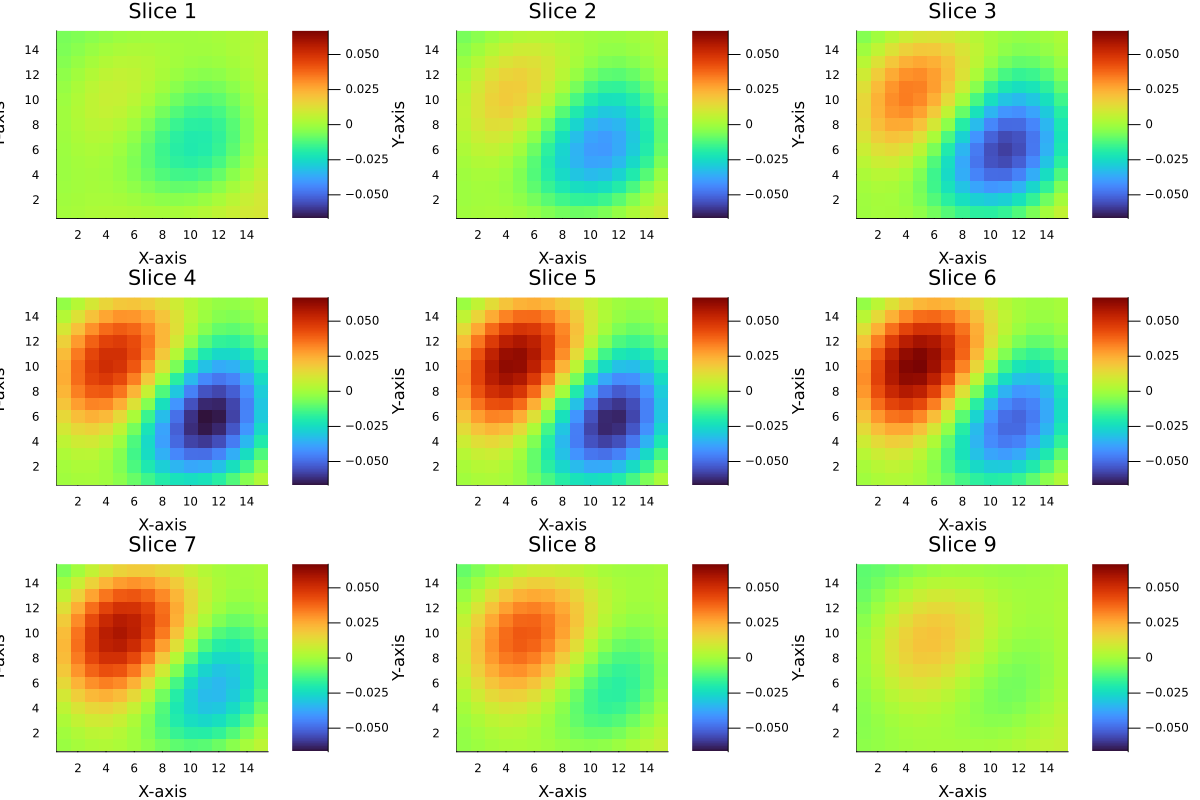

In [21]:
@time sleps = cuboidSleps(nslep, n, n, sl, Kp, N, N, N) 
Plots.plot(sleps..., size=(1200, 800))

 63.594580 seconds (132.48 M allocations: 695.082 GiB, 54.21% gc time)


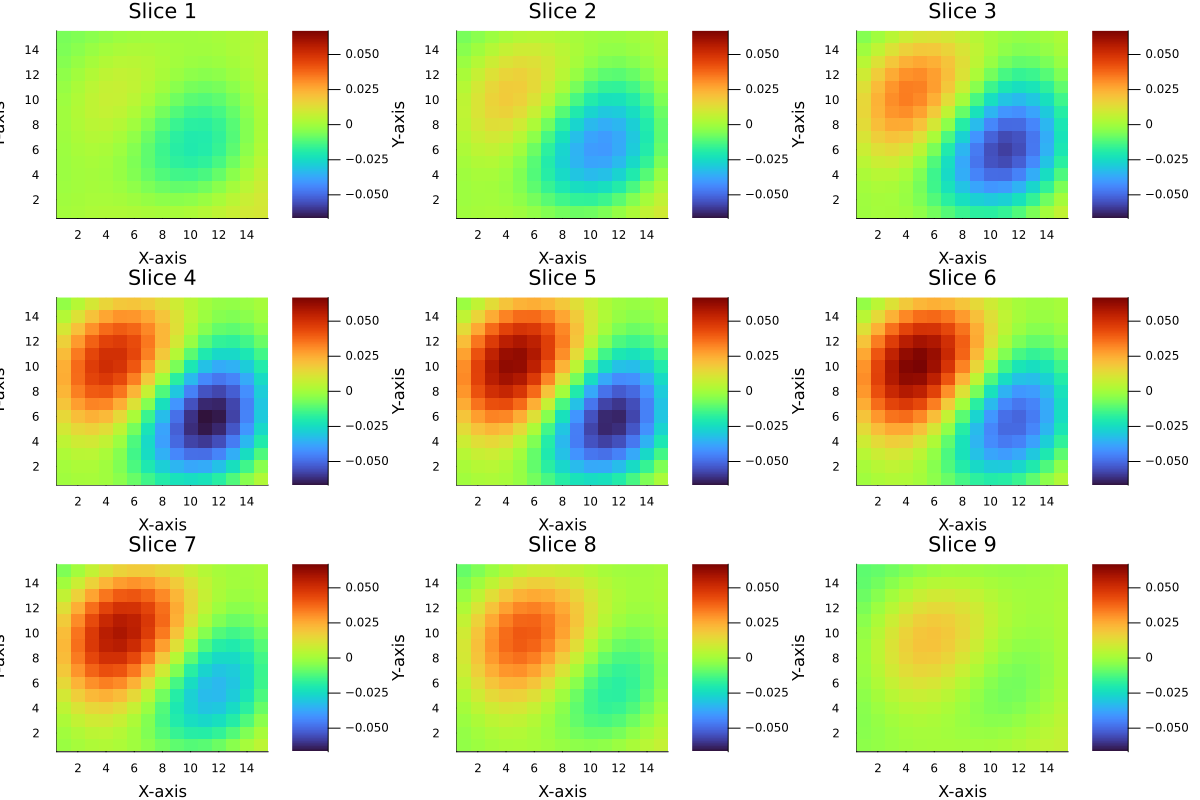

In [22]:
@time slepsNC = cuboidSlepsFastNC(nslep, n, n, sl, Kp, N, N, N) 
Plots.plot(slepsNC..., size=(1200, 800))

# Benchmarking the two methods
This clearly shows that for large datasets comparable to the target data sizes, the parallelized version performs more than twice as fast as the original.

In [23]:
@benchmark sleps = cuboidSleps(nslep, n, n, sl, Kp, N, N, N) 
#   6.485811 seconds (14.24 M allocations: 28.285 GiB, 22.17% gc time, 6.19% compilation time: 42% of which was recompilation)
# 110.521 s ± 770.520 ms #input:4, 15, 2.0, 15, 9
#  22.369 s ± 196.267 ms #input:4, 12, 2.0, 12, 9
# 134.002 s ± 767.663 ms #input:4, 15, 4.0, 15, 9

BenchmarkTools.Trial: 3 samples with 1 evaluation.
 Range (min … max):  133.343 s …  134.845 s  ┊ GC (min … max): 18.70% … 18.72%
 Time  (median):     133.817 s               ┊ GC (median):    18.80%
 Time  (mean ± σ):   134.002 s ± 767.663 ms  ┊ GC (mean ± σ):  18.74% ±  0.05%

  █                 █                                        █  
  █▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  133 s           Histogram: frequency by time           135 s <

 Memory estimate: 695.04 GiB, allocs estimate: 132135819.

In [24]:
@benchmark slepsNC = cuboidSlepsFastNC(nslep, n, n, 9, Kp, N, N, N) 
#  3.387303 seconds (12.25 M allocations: 26.195 GiB, 56.23% gc time, 15.68% compilation time)
# 33.481 s ± 218.105 ms #input:4, 15, 2.0, 15, 9
# 12.923 s ± 812.625 ms #input:4, 12, 2.0, 12, 9
# 53.485 s ±  4.860 s #input:4, 15, 4.0, 15, 9

BenchmarkTools.Trial: 6 samples with 1 evaluation.
 Range (min … max):  49.954 s … 59.815 s  ┊ GC (min … max): 46.91% … 39.29%
 Time  (median):     50.547 s             ┊ GC (median):    46.54%
 Time  (mean ± σ):   53.485 s ±  4.860 s  ┊ GC (mean ± σ):  43.98% ±  3.88%

  ▁ █ ▁                                                   █  
  █▁█▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁█ ▁
  50 s           Histogram: frequency by time        59.8 s <

 Memory estimate: 695.08 GiB, allocs estimate: 132476892.